In [ ]:
!pip install -q rasterio geopandas

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, glob, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.transform import from_bounds
from rasterio.features import geometry_mask
from scipy.stats import pearsonr, spearmanr
from itertools import combinations

warnings.filterwarnings('ignore')

# ── ajuste apenas esta linha ────────────────────────────────────────────
PASTA_PROJETO = '/content/drive/MyDrive/artigo 2'
# ────────────────────────────────────────────────────────────────────────

PASTA_SAIDA = os.path.join(PASTA_PROJETO, 'resultados')
PASTA_FIG   = os.path.join(PASTA_SAIDA, 'figuras')
os.makedirs(PASTA_FIG, exist_ok=True)

CRS_DESTINO = 'EPSG:31983'   # SIRGAS 2000 / UTM 23S
GRADE       = 1000
COEF_OSAVI  = 1.16           # (1 + L), com L = 0,16

VOOS        = ['voo1', 'voo2', 'voo3', 'voo4']
INDICES     = ['ndvi', 'osavi', 'rdvi']
PLATAFORMAS = ['pix4d', 'metashape', 'dronedeploy']
ROTULO      = {'pix4d': 'P4D', 'dronedeploy': 'DD', 'metashape': 'MS'}

print('projeto:', PASTA_PROJETO)
print('saída:  ', PASTA_SAIDA)

projeto: /content/drive/MyDrive/artigo 2
saída:   /content/drive/MyDrive/artigo 2/resultados


In [ ]:
def localizar_rasters():
    achados = {}
    for caminho in glob.glob(os.path.join(PASTA_PROJETO, '**', '*.tif'), recursive=True):
        if f'{os.sep}resultados{os.sep}' in caminho:
            continue
        nome = os.path.basename(caminho).lower()
        voo  = next((v for v in VOOS if v in nome), None)
        idx  = next((i for i in INDICES if i in nome), None)
        plat = next((p for p in PLATAFORMAS if p in nome), None)
        if voo and idx and plat:
            achados.setdefault(voo, {}).setdefault(idx, {})[plat] = caminho
    return achados


def localizar_mascaras():
    mascaras = {}
    for ext in ('*.geojson', '*.gpkg', '*.shp'):      # geojson tem prioridade
        for caminho in glob.glob(os.path.join(PASTA_PROJETO, '**', ext), recursive=True):
            nome = os.path.basename(caminho).lower()
            voo  = next((v for v in VOOS if v in nome), None)
            if voo and voo not in mascaras:
                mascaras[voo] = caminho
    return mascaras


ARQUIVOS = localizar_rasters()
MASCARAS = localizar_mascaras()

print('RASTERS')
print(f'{"":2}{"voo":6} {"índice":8} plataformas')
print('-' * 56)
for voo in VOOS:
    for idx in INDICES:
        p = sorted(ARQUIVOS.get(voo, {}).get(idx, {}))
        print(f'{"  " if len(p) >= 2 else "! "}{voo:6} {idx:8} {", ".join(p) or "nenhuma"}')

print('\n! = menos de duas plataformas, não será comparado')

print('\nMÁSCARAS')
for voo in VOOS:
    caminho = MASCARAS.get(voo)
    if caminho is None:
        print(f'! {voo}: NÃO ENCONTRADA')
        continue
    try:
        g = gpd.read_file(caminho)
        n_vazias = int(g.geometry.isna().sum() + (~g.geometry.is_valid).sum())
        b = g.total_bounds
        crs = g.crs.to_string() if g.crs else 'sem CRS'
        estado = 'ok' if np.isfinite(b).all() else 'GEOMETRIA VAZIA'
        print(f'  {voo}: {os.path.basename(caminho):28} {crs:12} {estado}')
        if np.isfinite(b).all():
            print(f'{"":9}bounds: {[round(v, 4) for v in b]}  feições: {len(g)}  inválidas: {n_vazias}')
    except Exception as e:
        print(f'! {voo}: erro ao ler — {type(e).__name__}: {e}')

RASTERS
  voo    índice   plataformas
--------------------------------------------------------
  voo1   ndvi     dronedeploy, metashape, pix4d
  voo1   osavi    dronedeploy, metashape, pix4d
  voo1   rdvi     dronedeploy, metashape, pix4d
  voo2   ndvi     dronedeploy, metashape, pix4d
  voo2   osavi    dronedeploy, metashape, pix4d
  voo2   rdvi     dronedeploy, metashape, pix4d
  voo3   ndvi     dronedeploy, metashape, pix4d
  voo3   osavi    dronedeploy, metashape, pix4d
  voo3   rdvi     dronedeploy, metashape, pix4d
  voo4   ndvi     dronedeploy, metashape, pix4d
  voo4   osavi    dronedeploy, metashape, pix4d
  voo4   rdvi     dronedeploy, metashape, pix4d

! = menos de duas plataformas, não será comparado

MÁSCARAS
  voo1: mascara_voo1.shp             EPSG:31983   ok
         bounds: [np.float64(-47.5487), np.float64(-22.6483), np.float64(-47.545), np.float64(-22.6419)]  feições: 1  inválidas: 0
  voo2: mascara_voo2.shp             EPSG:31983   ok
         bounds: [np.float64(-4

In [ ]:
def _pares(a, b):
    a = np.asarray(a, np.float64).ravel()
    b = np.asarray(b, np.float64).ravel()
    ok = np.isfinite(a) & np.isfinite(b)
    return a[ok], b[ok]


def ccc_lin(a, b):
    """Coeficiente de Concordância de Lin (1989):
       CCC = 2 r sx sy / (sx² + sy² + (mx − my)²)"""
    x, y = _pares(a, b)
    if x.size < 3:
        return np.nan
    sx, sy = x.std(ddof=0), y.std(ddof=0)
    if sx == 0 or sy == 0:
        return np.nan
    r, _ = pearsonr(x, y)
    return float(2 * r * sx * sy / (sx**2 + sy**2 + (x.mean() - y.mean())**2))


def classificar(v):
    """McBride (2005), NIWA Client Report HAM2005-062."""
    if not np.isfinite(v):      return 'indefinido'
    if v < 0.90:                return 'pobre'
    if v < 0.95:                return 'moderada'
    if v < 0.99:                return 'substancial'
    return 'quase perfeita'


def metricas(a, b, **ctx):
    x, y = _pares(a, b)
    saida = dict(ctx)
    if x.size < 3:
        return saida
    dif  = y - x
    bias = dif.mean()
    sd   = dif.std(ddof=0)
    r, _ = pearsonr(x, y)
    ccc  = ccc_lin(x, y)
    saida.update({
        'n_pixels': int(x.size),
        'media_a': round(float(x.mean()), 5),
        'media_b': round(float(y.mean()), 5),
        'R':  round(float(r), 4),
        'R2': round(float(r**2), 4),
        'spearman': round(float(spearmanr(x, y).statistic), 4),
        'CCC': round(ccc, 4),
        'classificacao': classificar(ccc),
        'RMSE': round(float(np.sqrt((dif**2).mean())), 5),
        'MAE':  round(float(np.abs(dif).mean()), 5),
        'bias': round(float(bias), 5),
        'sd_diff': round(float(sd), 5),
        'loa_inf': round(float(bias - 1.96*sd), 4),
        'loa_sup': round(float(bias + 1.96*sd), 4),
    })
    return saida


def ler_mascara(voo):
    """Lê a máscara e corrige CRS incoerente. Devolve None se inutilizável."""
    caminho = MASCARAS.get(voo)
    if caminho is None:
        return None
    try:
        shp = gpd.read_file(caminho)
    except Exception as e:
        print(f'  {voo}: falha ao ler máscara — {e}')
        return None

    shp = shp[shp.geometry.notna() & ~shp.geometry.is_empty]
    if len(shp) == 0 or not np.isfinite(shp.total_bounds).all():
        print(f'  {voo}: máscara sem geometria válida')
        return None

    x0, y0, _, _ = shp.total_bounds
    graus = (-180 <= x0 <= 180) and (-90 <= y0 <= 90)

    if shp.crs is None:
        shp = shp.set_crs('EPSG:4326' if graus else CRS_DESTINO)
    elif graus and not shp.crs.is_geographic:
        print(f'  {voo}: .prj diz {shp.crs.to_string()} mas as coordenadas são graus '
              f'— assumindo EPSG:4326')
        shp = shp.set_crs('EPSG:4326', allow_override=True)
    elif not graus and shp.crs.is_geographic:
        print(f'  {voo}: .prj diz geográfico mas as coordenadas são metros '
              f'— assumindo {CRS_DESTINO}')
        shp = shp.set_crs(CRS_DESTINO, allow_override=True)

    shp = shp.to_crs(CRS_DESTINO)
    area = shp.geometry.area.sum() / 10_000
    if area < 0.01:
        print(f'  {voo}: máscara com área {area:.4f} ha — descartada')
        return None
    return shp


def extensao_rasters(voo):
    """Interseção das extensões de todos os rasters do voo, em CRS_DESTINO."""
    caixas = []
    for plats in ARQUIVOS.get(voo, {}).values():
        for caminho in plats.values():
            with rasterio.open(caminho) as s:
                caixas.append(transform_bounds(s.crs, CRS_DESTINO, *s.bounds, densify_pts=21))
    if not caixas:
        return None
    return (max(c[0] for c in caixas), max(c[1] for c in caixas),
            min(c[2] for c in caixas), min(c[3] for c in caixas))


def carregar(caminho, transform):
    with rasterio.open(caminho) as src:
        destino = np.full((GRADE, GRADE), np.nan, np.float32)
        reproject(rasterio.band(src, 1), destino,
                  src_transform=src.transform, src_crs=src.crs, src_nodata=src.nodata,
                  dst_transform=transform, dst_crs=CRS_DESTINO, dst_nodata=np.nan,
                  resampling=Resampling.average)
    destino[destino < -1.5] = np.nan     # nodata −9999 do QGIS
    destino[destino >  3.0] = np.nan
    return destino


def preparar(voo):
    """Devolve (arrays, mascara_comum, origem_da_extensao) ou None."""
    shp = ler_mascara(voo)

    if shp is not None:
        transform = from_bounds(*shp.total_bounds, GRADE, GRADE)
        dentro = ~geometry_mask(shp.geometry, (GRADE, GRADE), transform, invert=False)
        origem = f'máscara ({shp.geometry.area.sum()/1e4:.2f} ha)'
    else:
        bounds = extensao_rasters(voo)
        if bounds is None:
            return None
        transform = from_bounds(*bounds, GRADE, GRADE)
        dentro = np.ones((GRADE, GRADE), bool)
        origem = 'interseção dos rasters (SEM máscara)'

    arrays = {idx: {p: carregar(c, transform) for p, c in plats.items()}
              for idx, plats in ARQUIVOS.get(voo, {}).items()}

    comum = dentro.copy()
    for d in arrays.values():
        for a in d.values():
            comum &= np.isfinite(a)

    print(f'{voo}: {origem} | {comum.sum():,} pixels comuns')
    if comum.sum() == 0:
        print(f'  {voo}: nenhum pixel em comum — verifique CRS e sobreposição')
        return None
    return arrays, comum, origem

In [ ]:
linhas, estatisticas, dados = [], [], {}

for voo in VOOS:
    if voo not in ARQUIVOS:
        print(f'{voo}: sem rasters, pulando')
        continue
    resultado = preparar(voo)
    if resultado is None:
        continue
    arrays, comum, origem = resultado
    dados[voo] = (arrays, comum)

    for idx, plats in arrays.items():
        for p, a in plats.items():
            v = a[comum]
            v = v[np.isfinite(v)]
            if v.size == 0:
                continue
            estatisticas.append({
                'voo': voo, 'indice': idx, 'plataforma': p, 'n_pixels': int(v.size),
                'min': round(float(v.min()), 5),   'max': round(float(v.max()), 5),
                'media': round(float(v.mean()), 5), 'desvio': round(float(v.std()), 5),
                'pct_acima_1': round(100 * float(np.mean(v > 1)), 3),
                'pct_abaixo_menos1': round(100 * float(np.mean(v < -1)), 3),
            })
        for pa, pb in combinations(sorted(plats), 2):
            linhas.append(metricas(
                np.where(comum, plats[pa], np.nan),
                np.where(comum, plats[pb], np.nan),
                voo=voo, indice=idx, par=f'{ROTULO[pa]} × {ROTULO[pb]}'))

df  = pd.DataFrame(linhas)
dfe = pd.DataFrame(estatisticas)
df.to_csv(f'{PASTA_SAIDA}/concordancia.csv', index=False)
dfe.to_csv(f'{PASTA_SAIDA}/estatisticas_rasters.csv', index=False)

tab = df.copy()
tab['LoA 95%'] = tab.apply(lambda r: f"{r['loa_inf']:.3f} a {r['loa_sup']:.3f}", axis=1)
tab = tab[['indice', 'voo', 'par', 'R2', 'CCC', 'classificacao', 'bias', 'LoA 95%']]
tab.columns = ['Índice', 'Voo', 'Par', 'R²', 'CCC', 'Concordância', 'Viés', 'LoA 95%']
tab = tab.sort_values(['Índice', 'Voo', 'Par'])
tab.to_csv(f'{PASTA_SAIDA}/tabela_artigo.csv', index=False)

print(f'\n{len(df)} pares | CCC ≥ 0,90: {int((df["CCC"] >= 0.90).sum())}')
tab

  voo1: .prj diz EPSG:31983 mas as coordenadas são graus — assumindo EPSG:4326
voo1: máscara (13.19 ha) | 490,586 pixels comuns
  voo2: .prj diz EPSG:31983 mas as coordenadas são graus — assumindo EPSG:4326
voo2: máscara (0.73 ha) | 389,185 pixels comuns
  voo3: .prj diz EPSG:31983 mas as coordenadas são graus — assumindo EPSG:4326
voo3: máscara (0.99 ha) | 411,726 pixels comuns
  voo4: .prj diz EPSG:31983 mas as coordenadas são graus — assumindo EPSG:4326
voo4: máscara (4.72 ha) | 540,170 pixels comuns

36 pares | CCC ≥ 0,90: 1


,Índice,Voo,Par,R²,CCC,Concordância,Viés,LoA 95%
6,ndvi,voo1,DD × MS,0.9460,0.9303,moderada,0.03863,-0.113 a 0.190
7,ndvi,voo1,DD × P4D,0.9102,0.2097,pobre,0.51991,0.403 a 0.637
8,ndvi,voo1,MS × P4D,0.9111,0.2794,pobre,0.48128,0.299 a 0.664
15,ndvi,voo2,DD × MS,0.2309,0.0249,pobre,-1.10189,-1.572 a -0.632
16,ndvi,voo2,DD × P4D,0.0634,0.0224,pobre,-0.68167,-1.064 a -0.299
17,ndvi,voo2,MS × P4D,0.4001,0.2245,pobre,0.42022,0.005 a 0.836
24,ndvi,voo3,DD × MS,0.0036,-0.0050,pobre,-0.94585,-1.527 a -0.364
25,ndvi,voo3,DD × P4D,0.0004,0.0035,pobre,-0.50035,-0.952 a -0.049
26,ndvi,voo3,MS × P4D,0.4588,0.1650,pobre,0.44550,0.121 a 0.770
33,ndvi,voo4,DD × MS,0.0271,0.0085,pobre,-0.83730,-1.238 a -0.437


In [ ]:
escala = []
for voo, (arrays, comum) in dados.items():
    if not {'ndvi', 'osavi', 'rdvi'} <= set(arrays):
        continue
    plats = set(arrays['ndvi']) & set(arrays['osavi']) & set(arrays['rdvi'])
    for plat in plats:
        n = arrays['ndvi'][plat][comum]
        o = arrays['osavi'][plat][comum]
        r = arrays['rdvi'][plat][comum]
        m = np.isfinite(n) & np.isfinite(o) & np.isfinite(r) & (n > 0.05)
        if m.sum() < 100:
            continue
        n, o, r = n[m], o[m], r[m]

        # NIR+RED implícito, recuperado das definições dos dois índices
        s_osavi = 0.16 * o / (COEF_OSAVI * n - o)
        s_rdvi  = (r / n) ** 2
        ok = np.isfinite(s_osavi) & np.isfinite(s_rdvi) & (s_osavi > 0) & (s_osavi < 5)
        if ok.sum() < 100:
            continue

        escala.append({
            'voo': voo, 'plataforma': plat,
            'ndvi_medio':  round(float(n.mean()), 5),
            'osavi_medio': round(float(o.mean()), 5),
            'rdvi_medio':  round(float(r.mean()), 5),
            'nir_red_via_osavi': round(float(np.median(s_osavi[ok])), 5),
            'nir_red_via_rdvi':  round(float(np.median(s_rdvi[ok])), 5),
            'correlacao': round(float(np.corrcoef(s_osavi[ok], s_rdvi[ok])[0, 1]), 3),
        })

dfs = pd.DataFrame(escala)
if len(dfs):
    dfs = dfs.sort_values(['voo', 'plataforma'])
    dfs.to_csv(f'{PASTA_SAIDA}/diagnostico_escala.csv', index=False)
    print('Esperado para vegetação: NIR+RED entre 0,3 e 0,7\n')
dfs

Esperado para vegetação: NIR+RED entre 0,3 e 0,7



,voo,plataforma,ndvi_medio,osavi_medio,rdvi_medio,nir_red_via_osavi,nir_red_via_rdvi,correlacao
0,voo1,dronedeploy,0.24228,-0.06886,-0.04655,0.00408,0.00032,0.908
2,voo1,metashape,0.30315,0.24775,0.18835,0.38136,0.38382,0.999
1,voo1,pix4d,0.68307,0.02315,0.04713,0.00478,0.00477,1.000
3,voo2,dronedeploy,1.28678,-0.03700,-0.02363,0.00605,0.00111,0.946
5,voo2,metashape,0.33018,0.26445,0.20225,0.37465,0.37845,1.000
4,voo2,pix4d,0.60512,0.01410,0.03410,0.00317,0.00316,1.000
6,voo3,dronedeploy,1.28112,-0.17257,-0.11192,0.00808,0.00121,0.919
8,voo3,metashape,0.39701,0.30632,0.23093,0.35275,0.35668,1.000
7,voo3,pix4d,0.78070,0.02587,0.05248,0.00467,0.00465,1.000
9,voo4,dronedeploy,1.54610,-0.08984,-0.06446,0.02482,0.01318,0.973


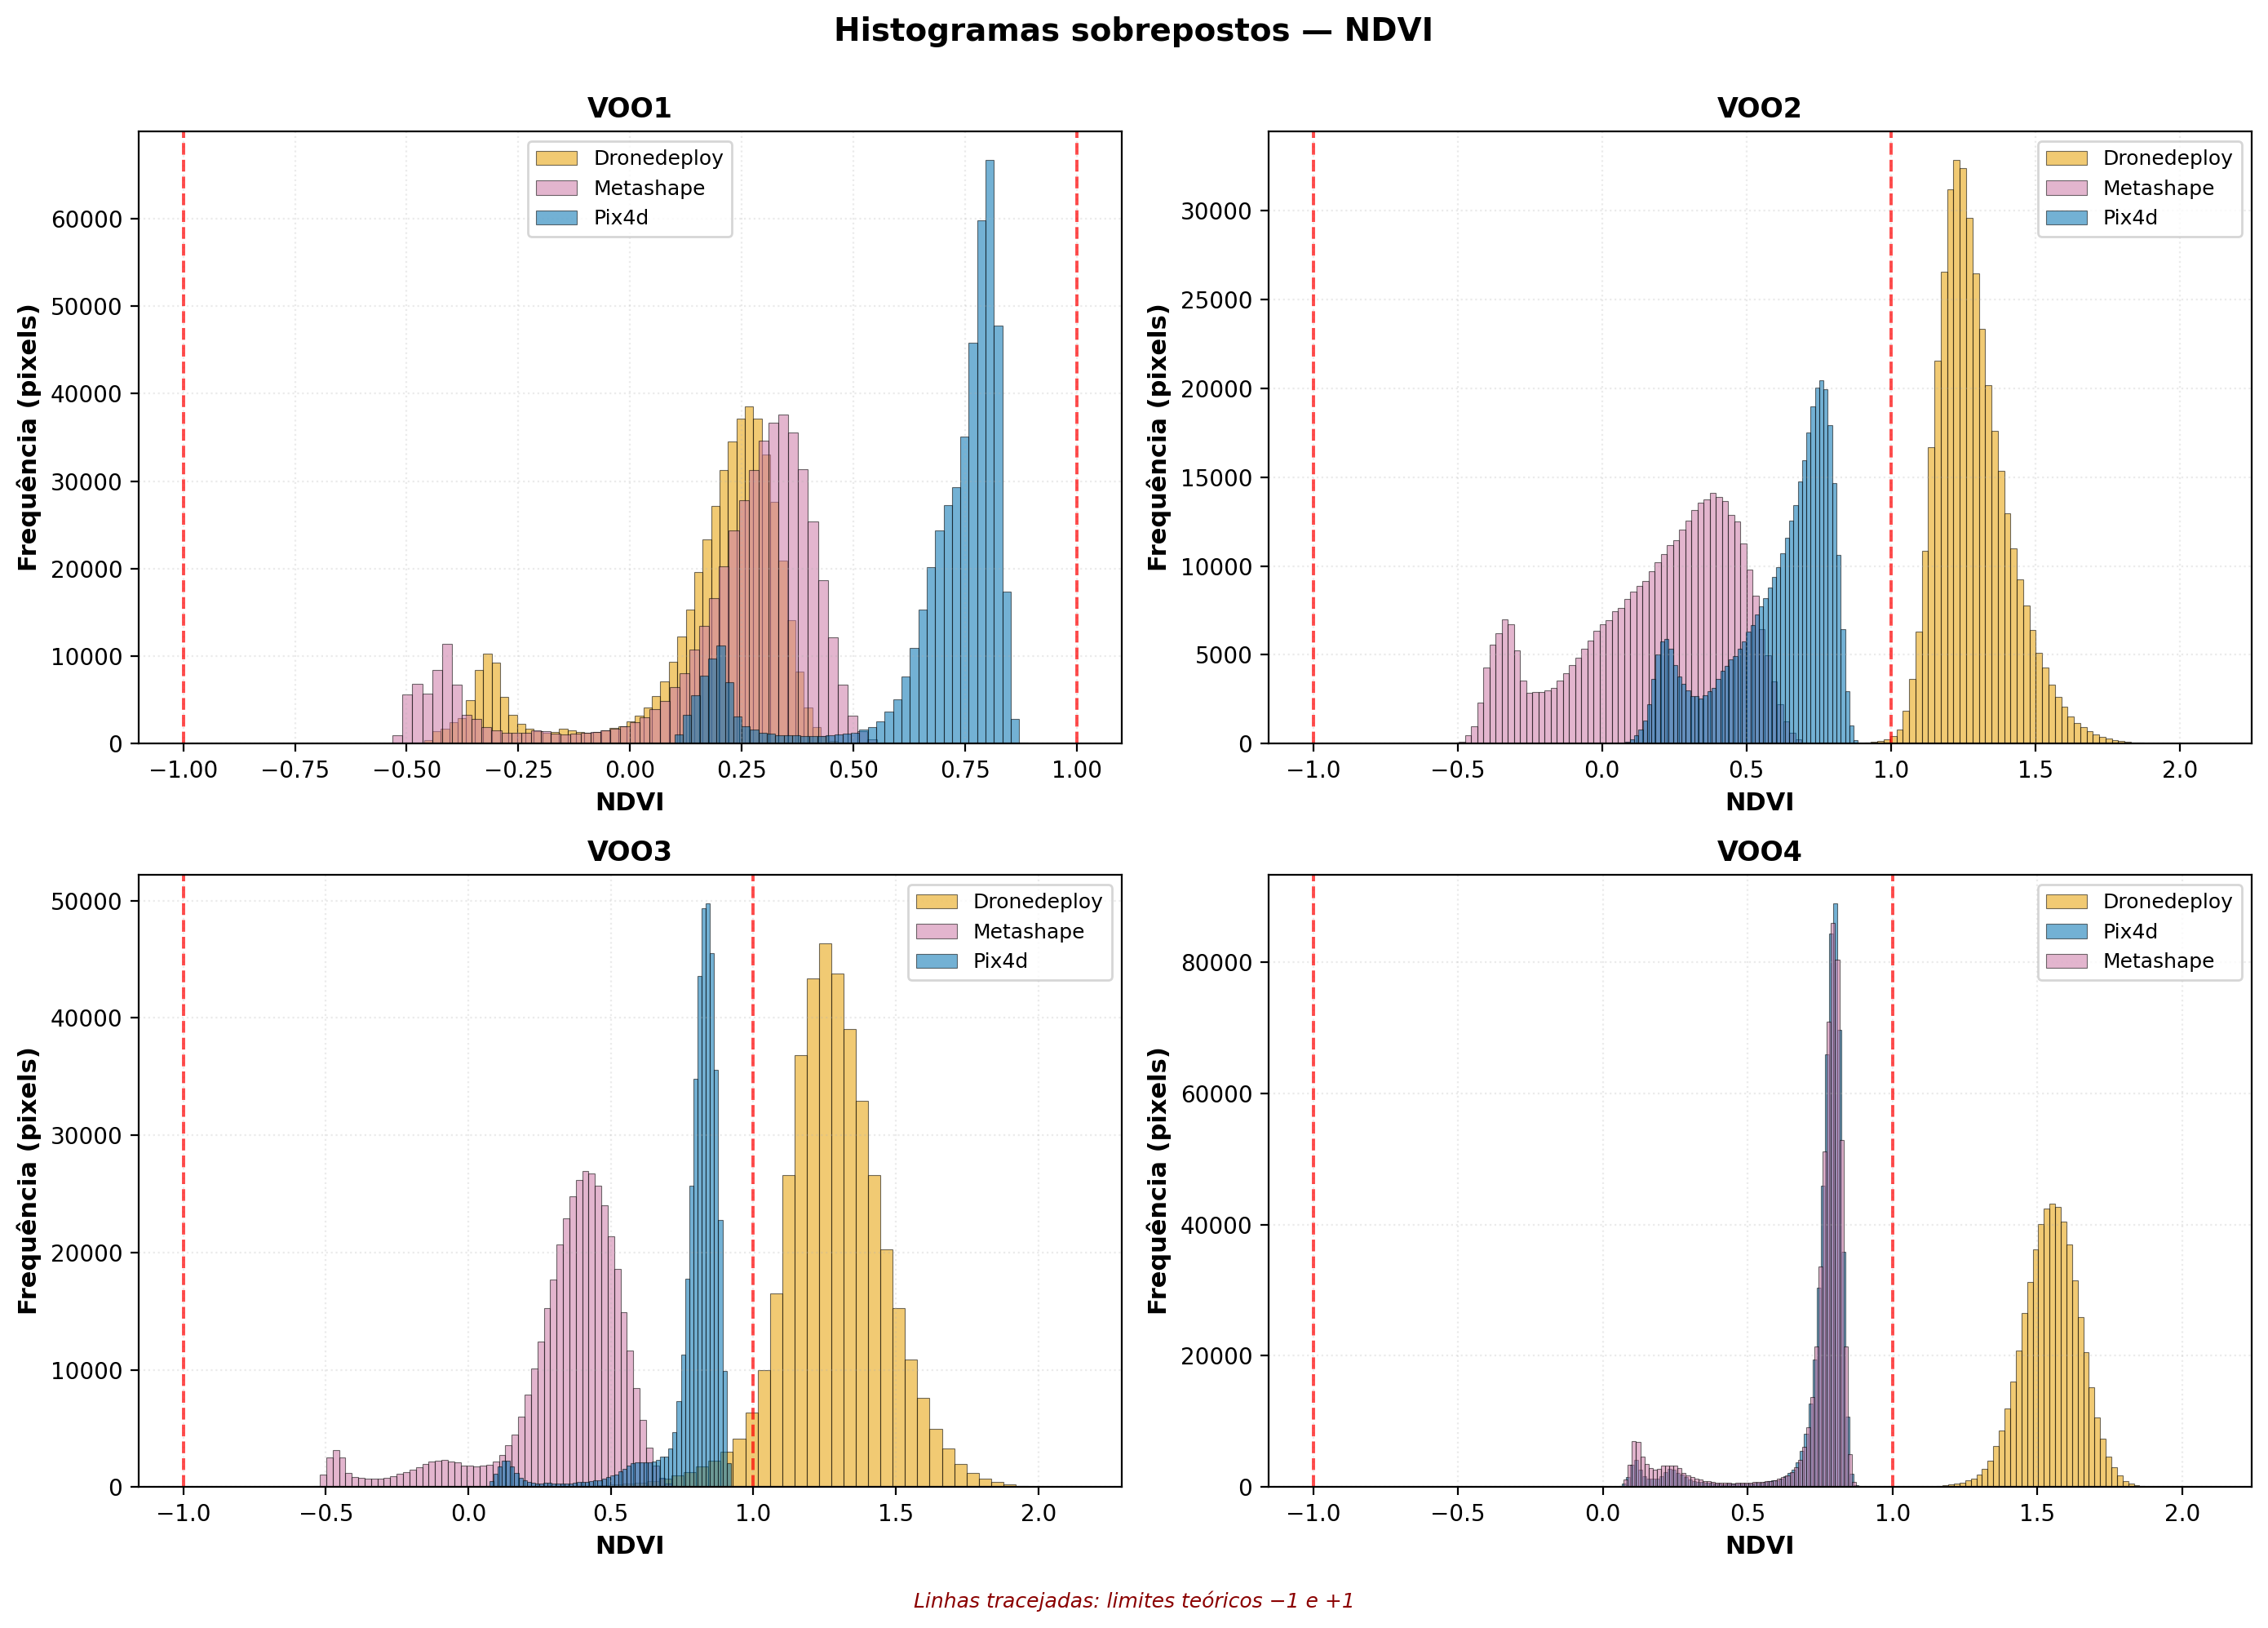

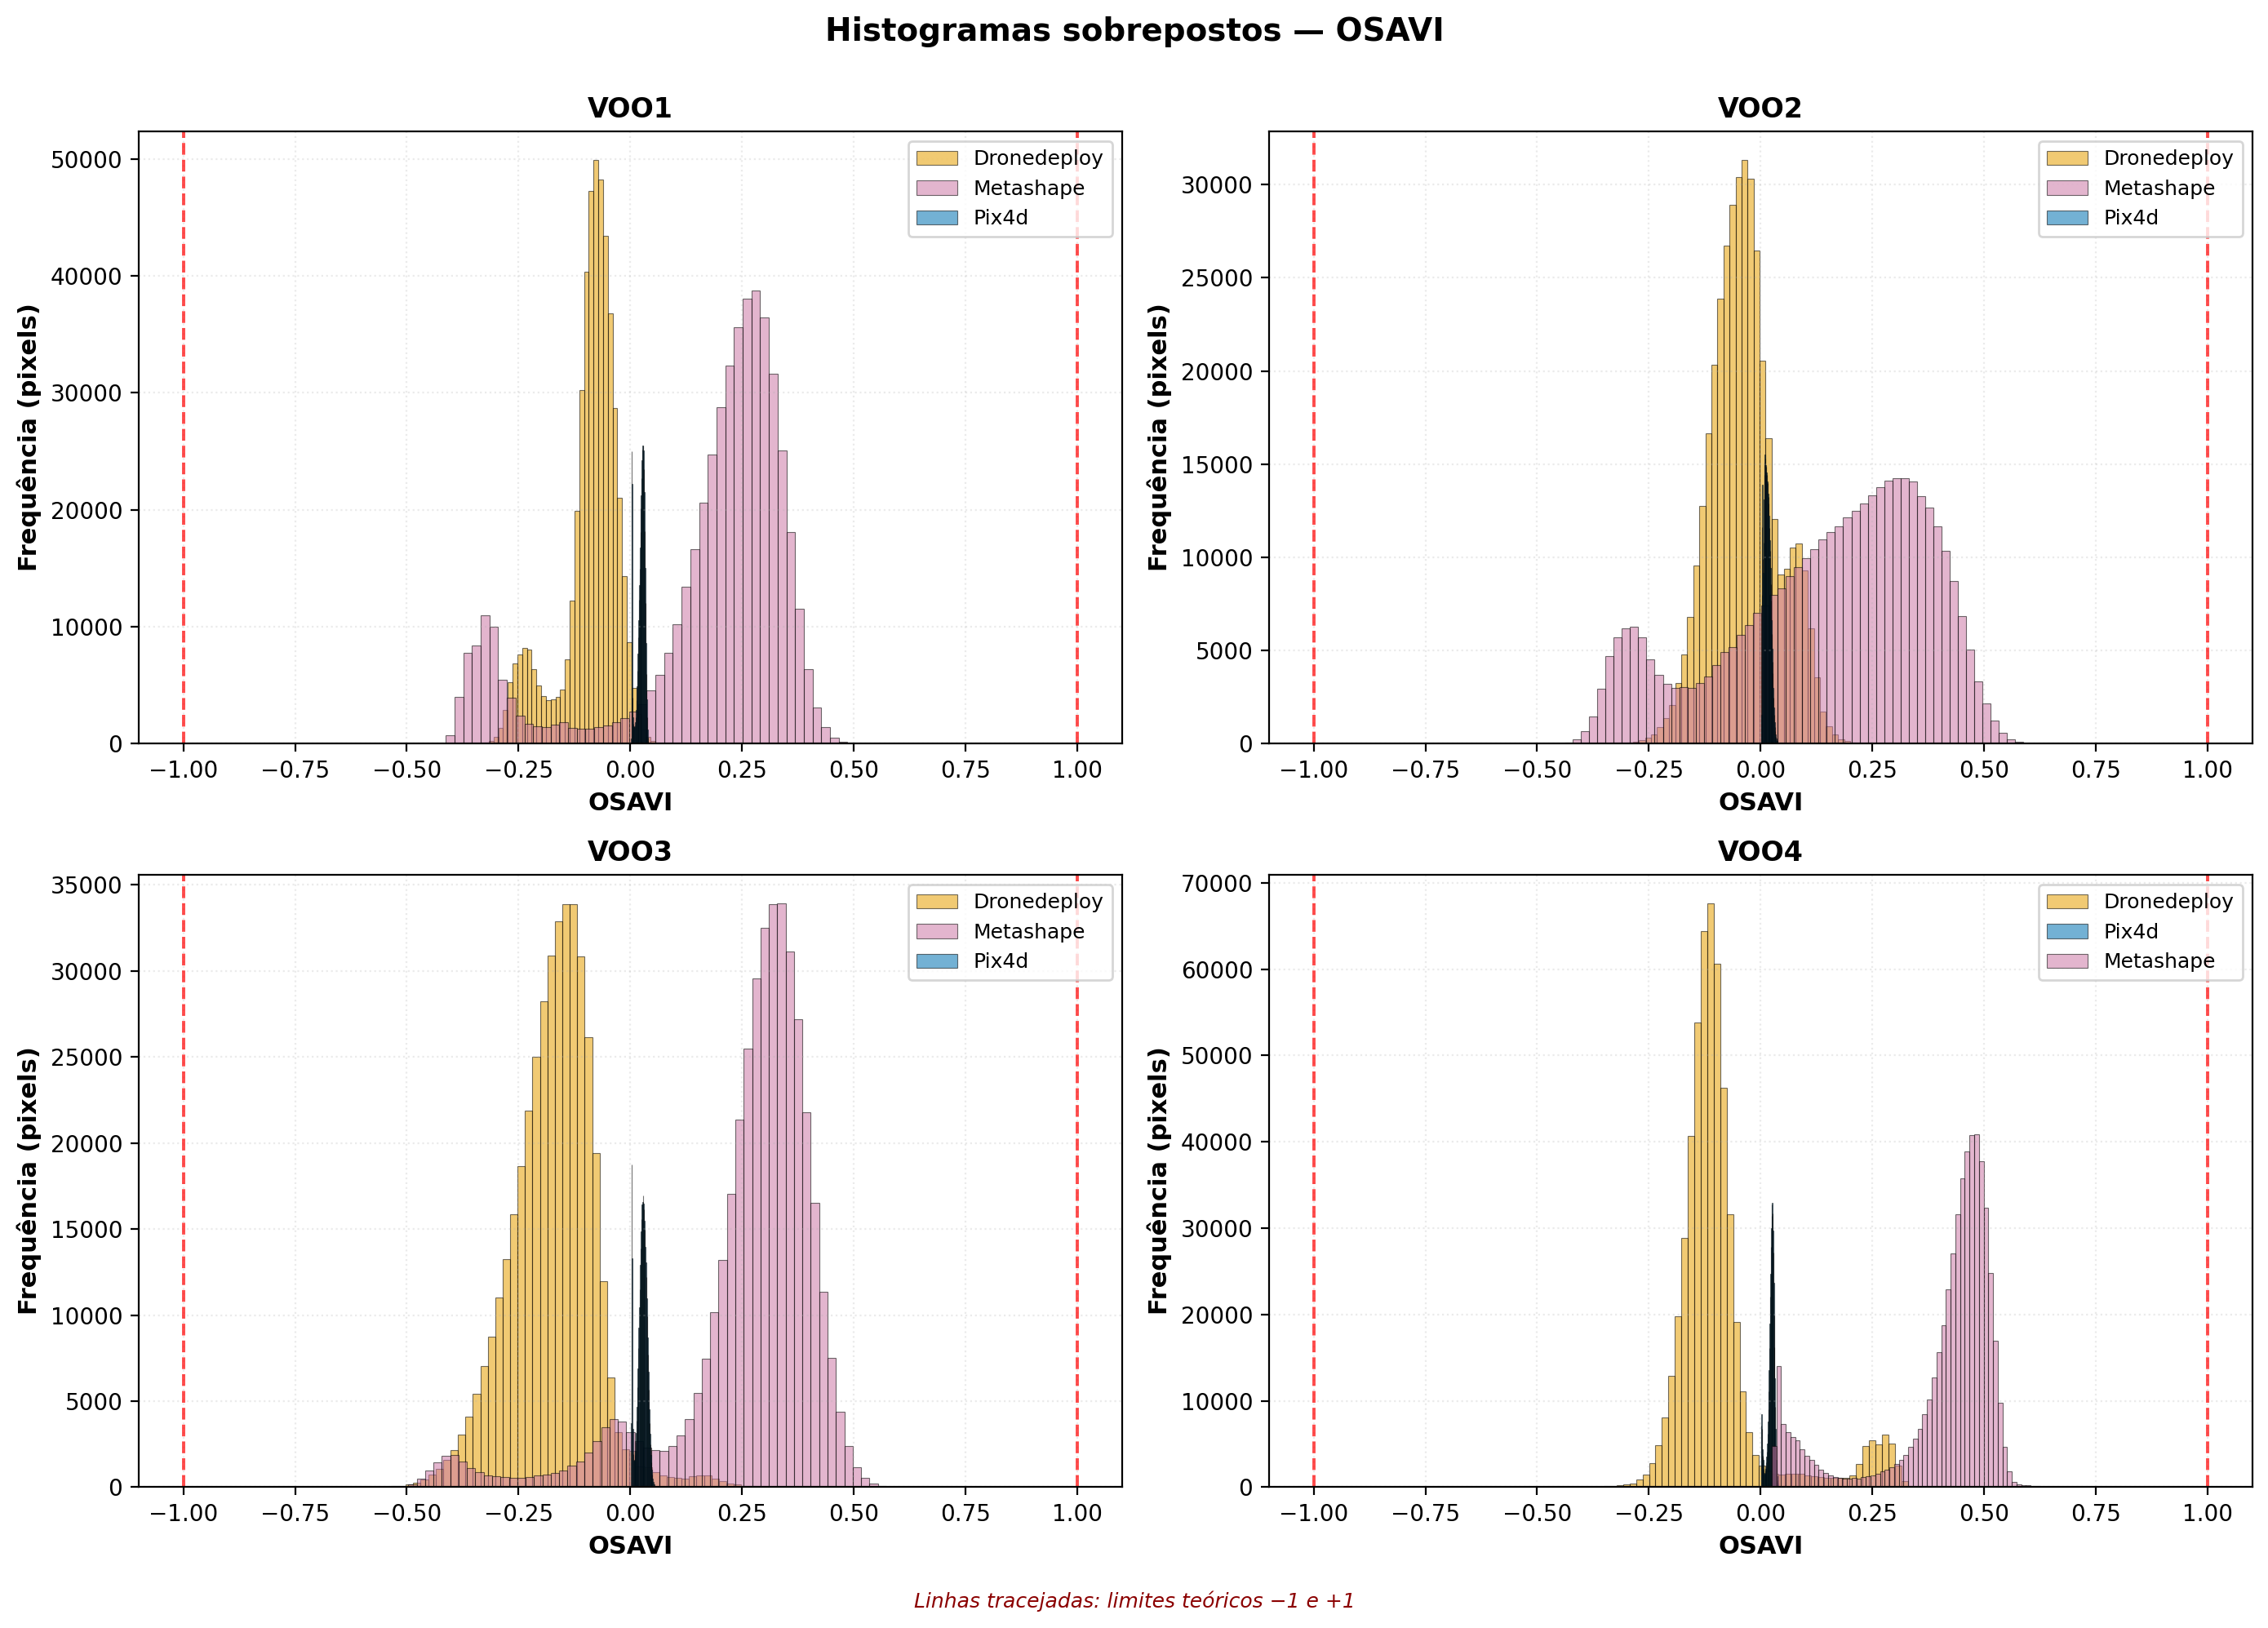

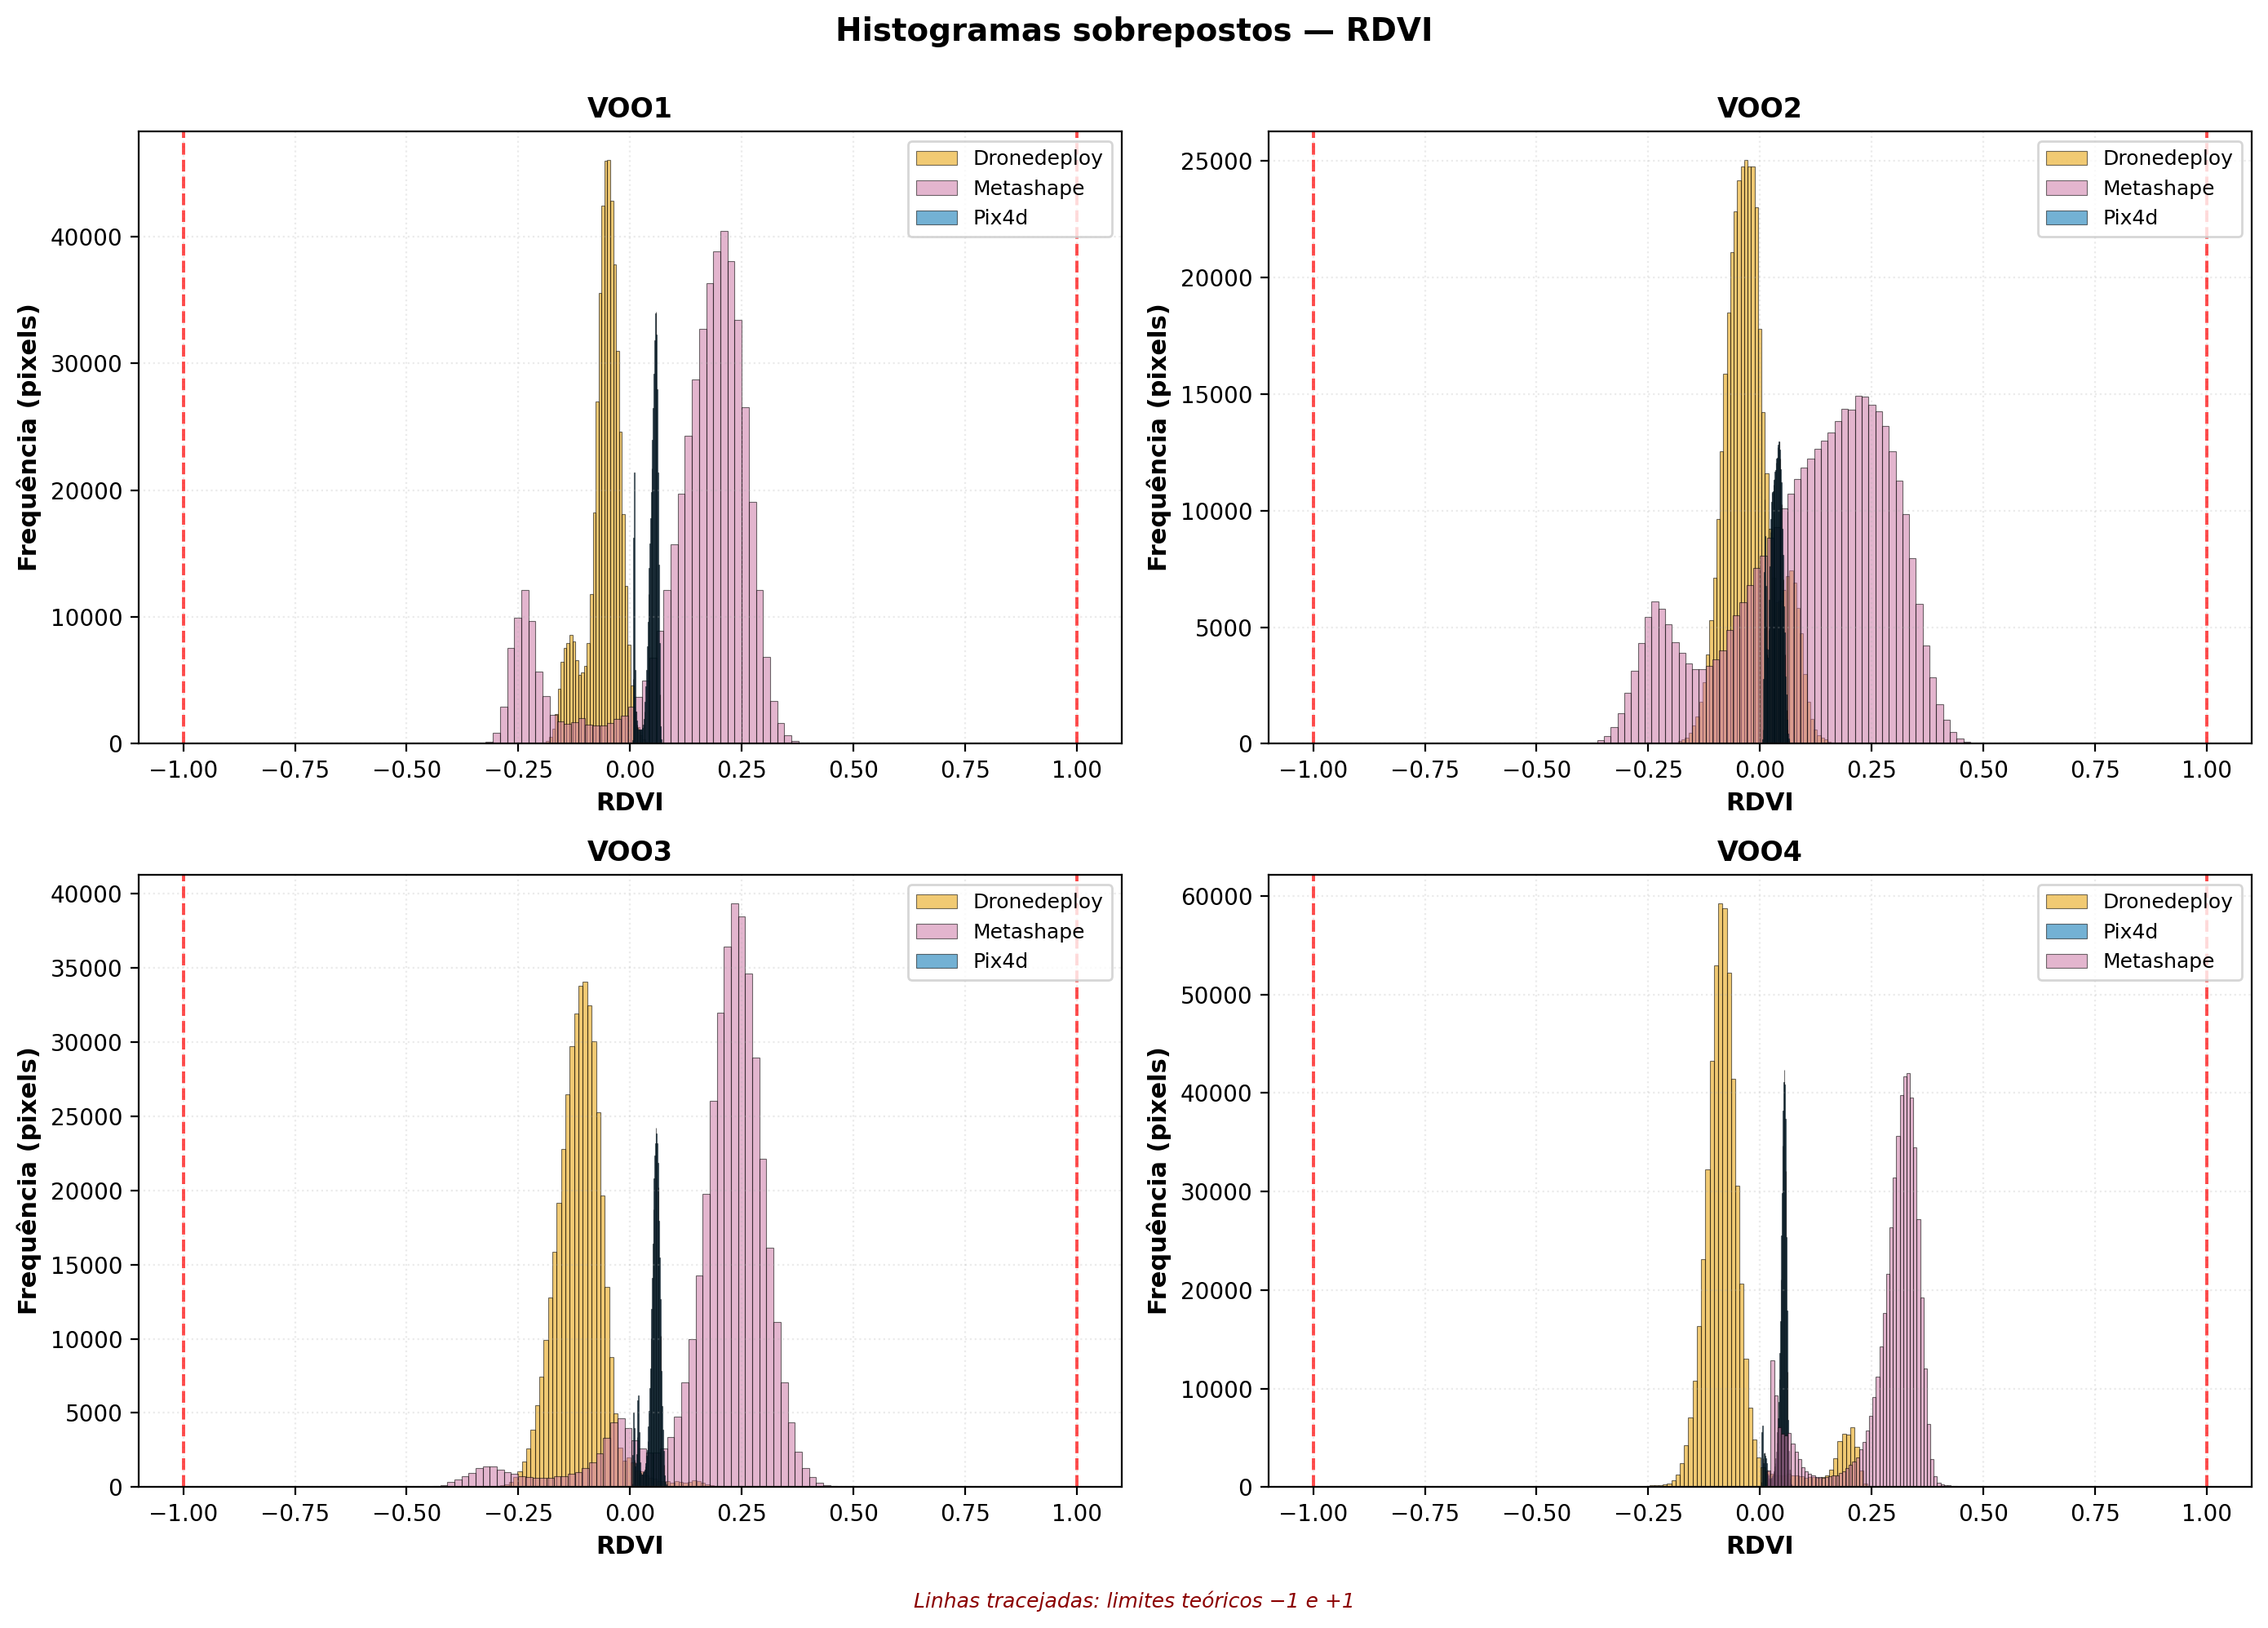

Figuras em /content/drive/MyDrive/artigo 2/resultados/figuras


In [ ]:
import matplotlib.pyplot as plt

CORES = {'pix4d': '#0072B2', 'dronedeploy': '#E69F00', 'metashape': '#CC79A7'}
MAX_PONTOS = 150_000


def bland_altman(a, b, titulo, caminho):
    x, y = _pares(a, b)
    dif = y - x
    bias, sd = dif.mean(), dif.std(ddof=0)
    inf, sup = bias - 1.96*sd, bias + 1.96*sd

    media = (x + y) / 2
    if media.size > MAX_PONTOS:
        i = np.random.default_rng(42).choice(media.size, MAX_PONTOS, replace=False)
        media, dif = media[i], dif[i]

    fig, ax = plt.subplots(figsize=(7, 5), dpi=200)
    ax.scatter(media, dif, s=3, alpha=0.2, edgecolors='none', color='steelblue')
    ax.axhline(bias, color='firebrick', lw=1.6, label=f'Viés = {bias:.3f}')
    for lim in (inf, sup):
        ax.axhline(lim, color='firebrick', ls='--', lw=1.2)
    ax.axhline(0, color='grey', lw=0.8, ls=':')
    ax.set_xlabel('Média das duas plataformas', fontsize=11)
    ax.set_ylabel('Diferença (B − A)', fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.25, ls=':')
    ax.annotate(f'LoA: {inf:.3f} a {sup:.3f}', xy=(0.99, 0.02),
                xycoords='axes fraction', ha='right', fontsize=9, color='firebrick')
    fig.tight_layout()
    fig.savefig(caminho, dpi=300, bbox_inches='tight')
    plt.close(fig)


for voo, (arrays, comum) in dados.items():
    for idx, plats in arrays.items():
        for pa, pb in combinations(sorted(plats), 2):
            bland_altman(
                np.where(comum, plats[pa], np.nan),
                np.where(comum, plats[pb], np.nan),
                f'{idx.upper()} — {voo.upper()} — {ROTULO[pa]} × {ROTULO[pb]}',
                os.path.join(PASTA_FIG,
                             f'ba_{voo}_{idx}_{ROTULO[pa]}_{ROTULO[pb]}.png'.lower()))

for indice in INDICES:
    voos_com = [v for v in VOOS if v in dados and indice in dados[v][0]]
    if not voos_com:
        continue
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=200)
    axes = axes.flatten()
    for eixo, voo in zip(axes, voos_com):
        arrays, comum = dados[voo]
        for plat, arr in arrays[indice].items():
            v = arr[comum]
            v = v[np.isfinite(v)]
            eixo.hist(v, bins=60, alpha=0.55, label=plat.capitalize(),
                      color=CORES.get(plat), edgecolor='black', linewidth=0.4)
        for limite in (-1, 1):
            eixo.axvline(limite, color='red', ls='--', lw=1.4, alpha=0.7)
        eixo.set_xlabel(indice.upper(), fontsize=11, fontweight='bold')
        eixo.set_ylabel('Frequência (pixels)', fontsize=11, fontweight='bold')
        eixo.set_title(voo.upper(), fontsize=12, fontweight='bold')
        eixo.legend(fontsize=9)
        eixo.grid(alpha=0.25, ls=':')
    for eixo in axes[len(voos_com):]:
        eixo.set_visible(False)
    fig.suptitle(f'Histogramas sobrepostos — {indice.upper()}', fontsize=14, fontweight='bold')
    fig.text(0.5, 0.005, 'Linhas tracejadas: limites teóricos −1 e +1',
             ha='center', fontsize=9, style='italic', color='darkred')
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])
    fig.savefig(f'{PASTA_FIG}/histogramas_{indice}.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Figuras em', PASTA_FIG)

In [ ]:
import rasterio
caminho = ARQUIVOS['voo4']['ndvi']['metashape']
print(caminho)
with rasterio.open(caminho) as s:
    a = s.read(1)
    a = a[a > -9998]
    print('min', a.min(), 'max', a.max(), 'média', a.mean())

/content/drive/MyDrive/artigo 2/voo4/NDVI_voo4_metashape.tif
min -0.6230492 max 1.0 média 0.67228794


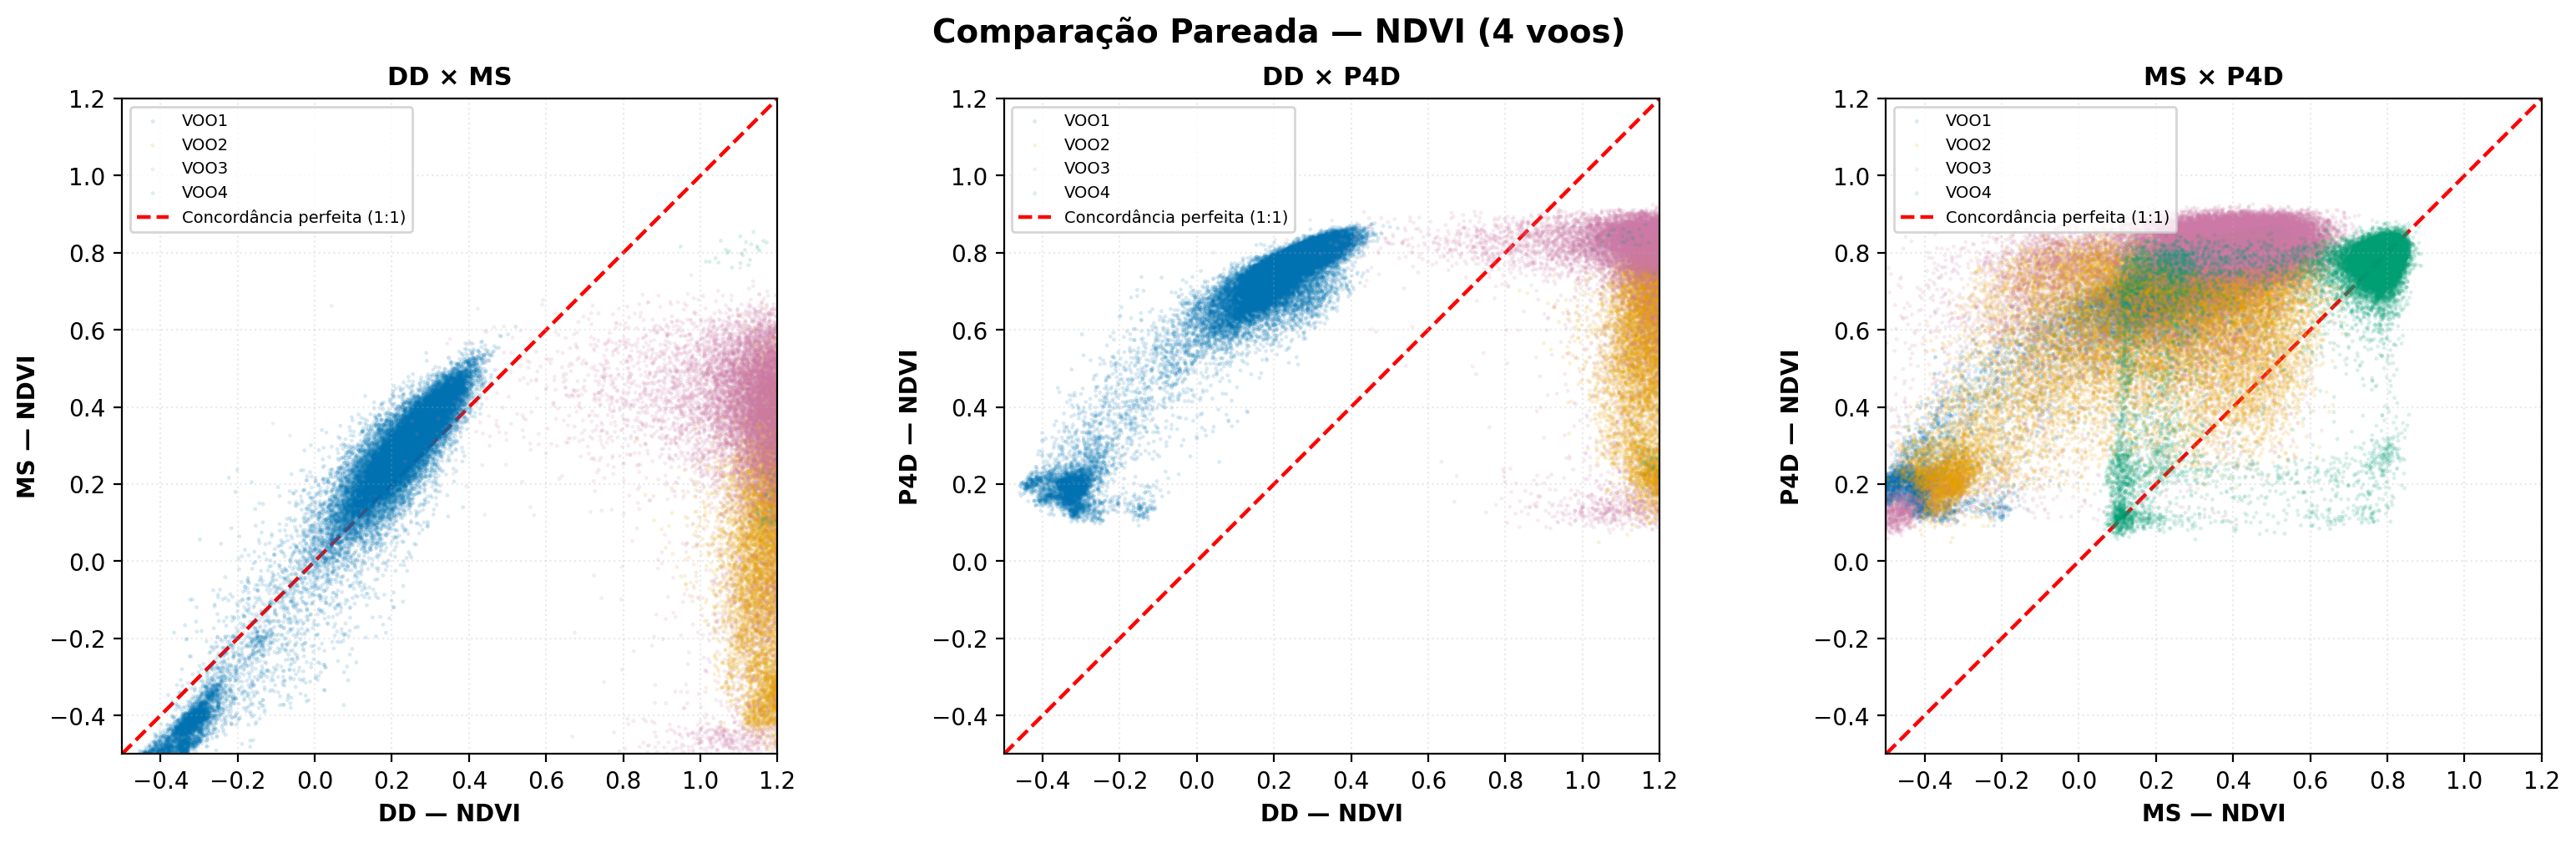

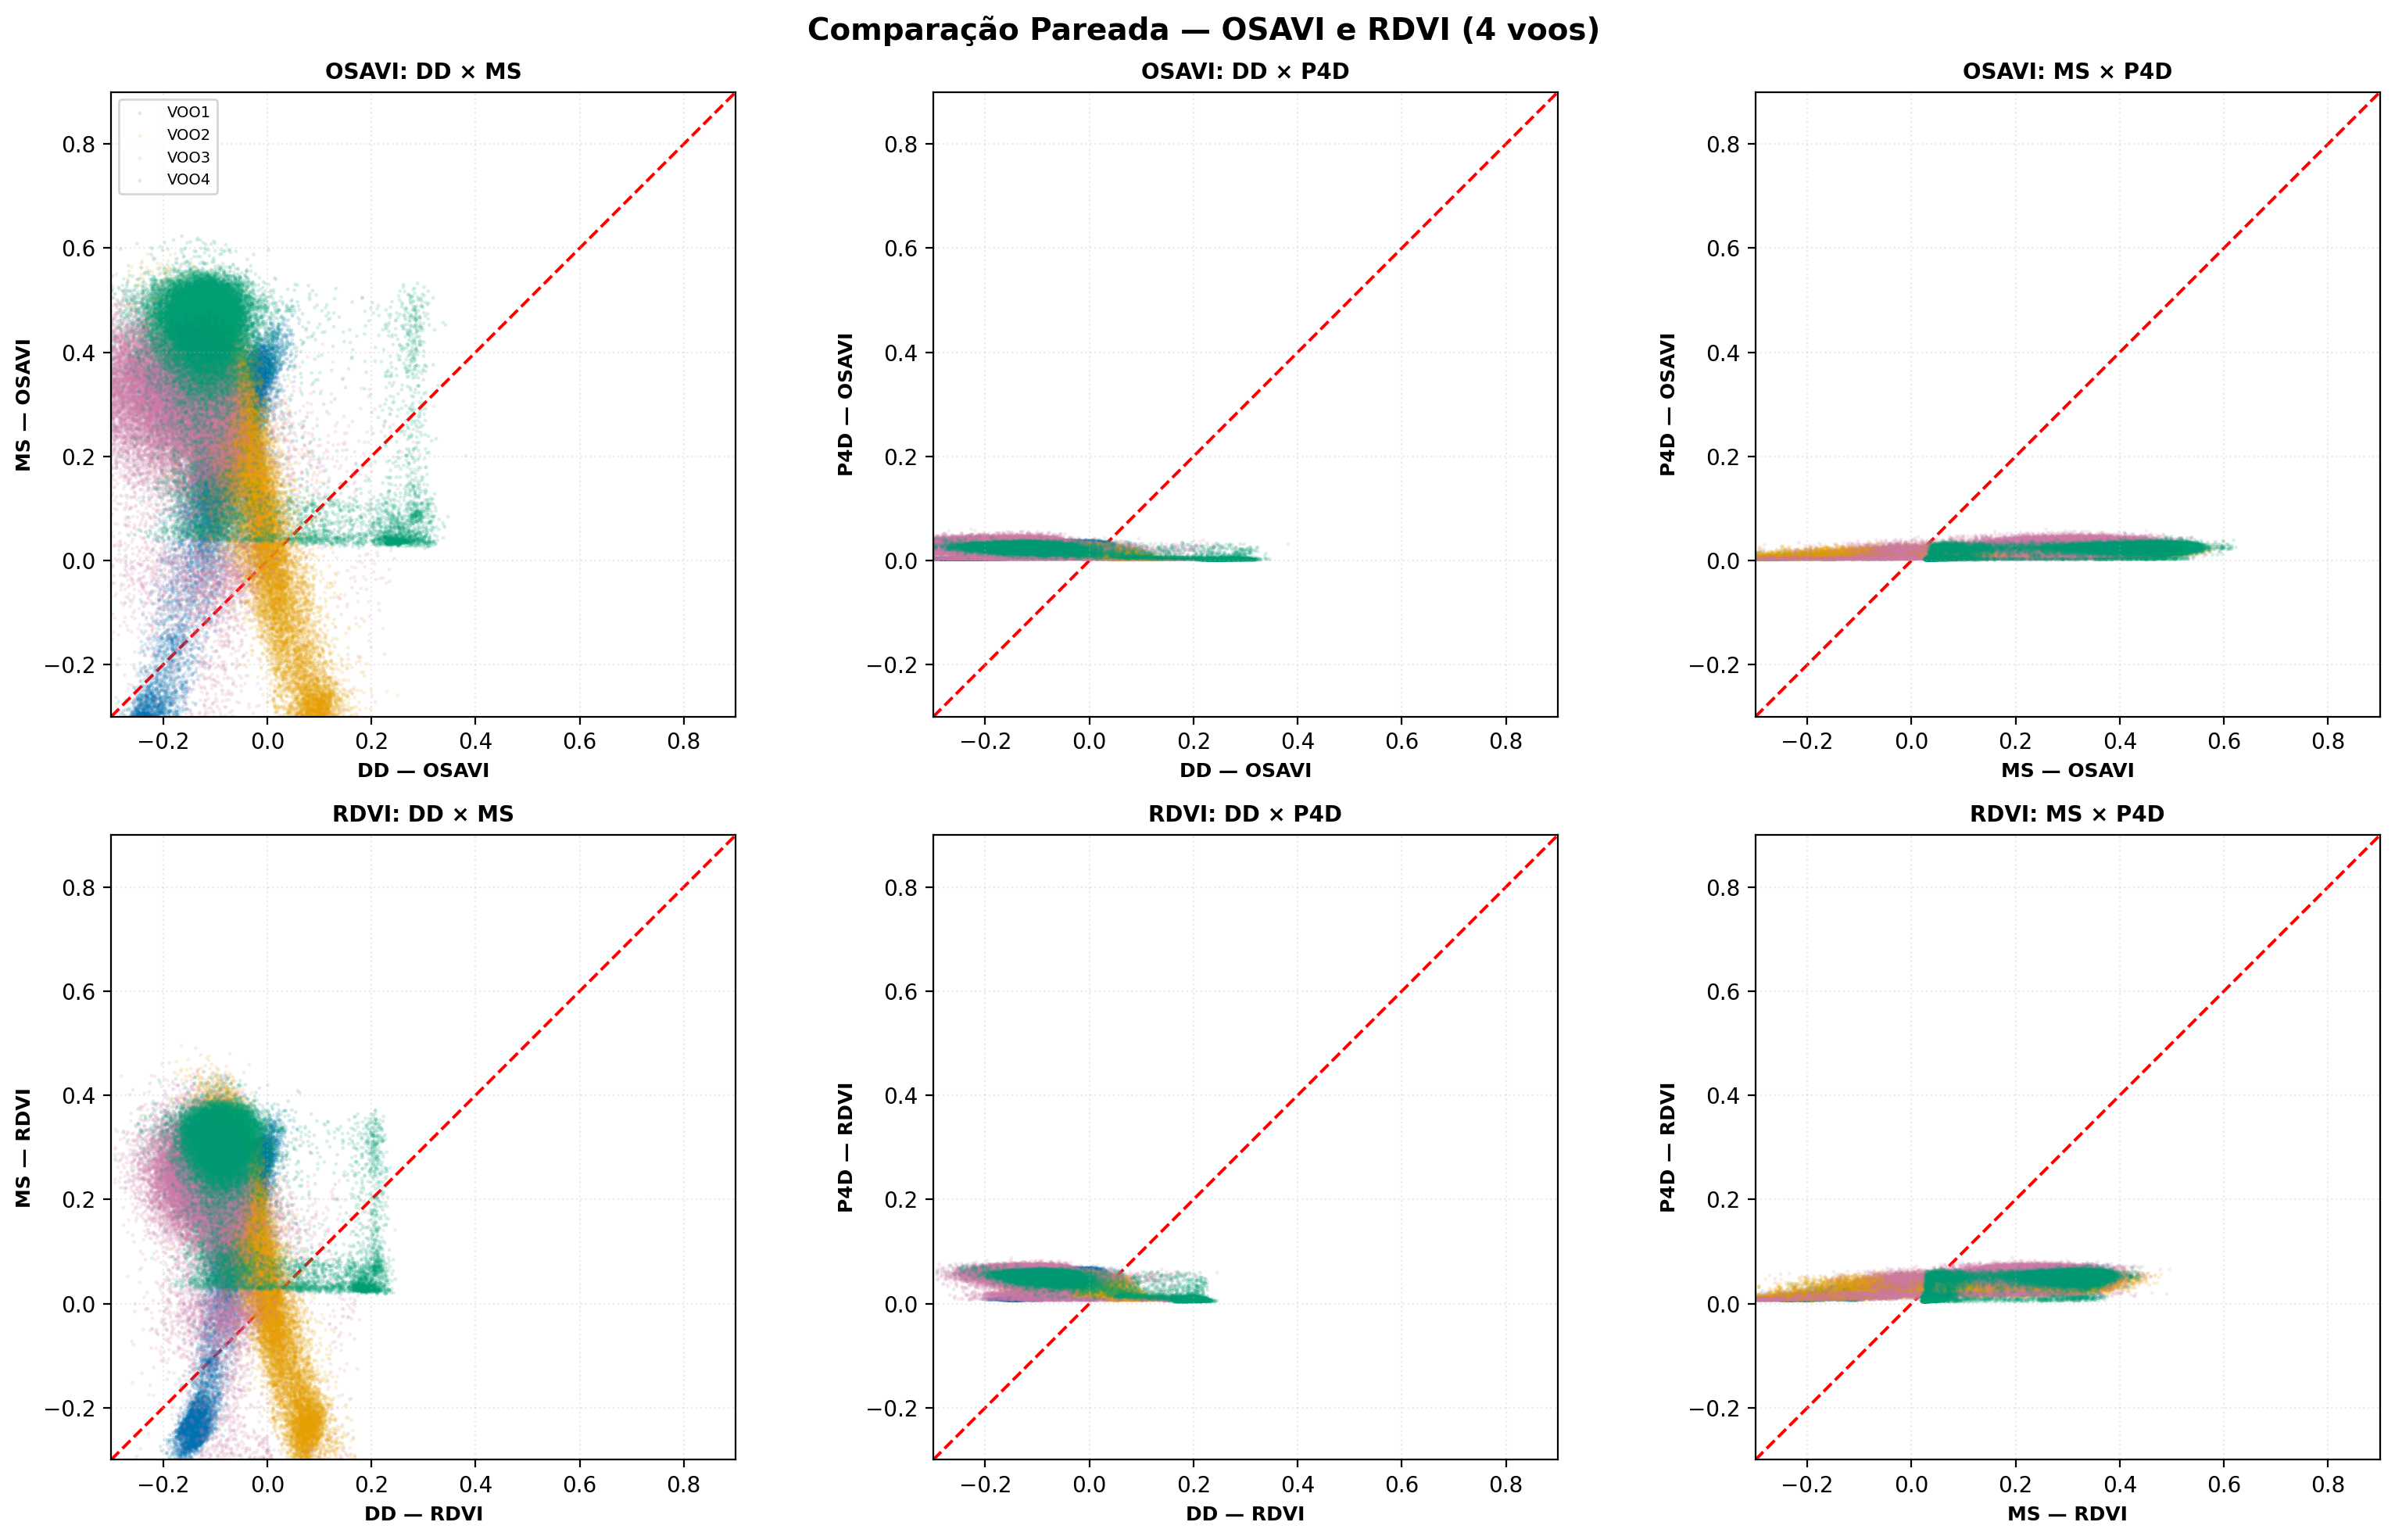

Figuras salvas em /content/drive/MyDrive/artigo 2/resultados/figuras


In [ ]:
CORES_VOO = {'voo1': '#0072B2', 'voo2': '#E69F00', 'voo3': '#CC79A7', 'voo4': '#009E73'}
PARES_ORDEM = [('dronedeploy','metashape'), ('dronedeploy','pix4d'), ('metashape','pix4d')]
MAX_PONTOS = 30_000

def scatter_indice(indice, titulo, caminho):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=200)
    for ax, (pa, pb) in zip(axes, PARES_ORDEM):
        for voo, (arrays, comum) in dados.items():
            if indice not in arrays or pa not in arrays[indice] or pb not in arrays[indice]:
                continue
            x = np.where(comum, arrays[indice][pa], np.nan)
            y = np.where(comum, arrays[indice][pb], np.nan)
            xf, yf = _pares(x, y)
            if xf.size > MAX_PONTOS:
                i = np.random.default_rng(0).choice(xf.size, MAX_PONTOS, replace=False)
                xf, yf = xf[i], yf[i]
            ax.scatter(xf, yf, s=3, alpha=0.15, color=CORES_VOO[voo], label=voo.upper(), edgecolors='none')
        lims = [-0.5, 1.2] if indice == 'ndvi' else [-0.3, 0.9]
        ax.plot(lims, lims, 'r--', lw=1.6, label='Concordância perfeita (1:1)', zorder=0)
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
        ax.set_xlabel(f'{ROTULO[pa]} — {indice.upper()}', fontsize=10, fontweight='bold')
        ax.set_ylabel(f'{ROTULO[pb]} — {indice.upper()}', fontsize=10, fontweight='bold')
        ax.set_title(f'{ROTULO[pa]} × {ROTULO[pb]}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.25, ls=':')
        ax.legend(fontsize=7, loc='upper left')
    fig.suptitle(titulo, fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.savefig(caminho, dpi=300, bbox_inches='tight')
    plt.show()

scatter_indice('ndvi', 'Comparação Pareada — NDVI (4 voos)',
               os.path.join(PASTA_FIG, 'scatter_ndvi.png'))

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=200)
for linha, indice in enumerate(['osavi', 'rdvi']):
    for col, (pa, pb) in enumerate(PARES_ORDEM):
        ax = axes[linha, col]
        for voo, (arrays, comum) in dados.items():
            if indice not in arrays or pa not in arrays[indice] or pb not in arrays[indice]:
                continue
            x = np.where(comum, arrays[indice][pa], np.nan)
            y = np.where(comum, arrays[indice][pb], np.nan)
            xf, yf = _pares(x, y)
            if xf.size > MAX_PONTOS:
                i = np.random.default_rng(0).choice(xf.size, MAX_PONTOS, replace=False)
                xf, yf = xf[i], yf[i]
            ax.scatter(xf, yf, s=3, alpha=0.15, color=CORES_VOO[voo], label=voo.upper(), edgecolors='none')
        lims = [-0.3, 0.9]
        ax.plot(lims, lims, 'r--', lw=1.4, zorder=0)
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
        ax.set_xlabel(f'{ROTULO[pa]} — {indice.upper()}', fontsize=9, fontweight='bold')
        ax.set_ylabel(f'{ROTULO[pb]} — {indice.upper()}', fontsize=9, fontweight='bold')
        ax.set_title(f'{indice.upper()}: {ROTULO[pa]} × {ROTULO[pb]}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.25, ls=':')
        if linha == 0 and col == 0:
            ax.legend(fontsize=7, loc='upper left')
fig.suptitle('Comparação Pareada — OSAVI e RDVI (4 voos)', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(PASTA_FIG, 'scatter_osavi_rdvi.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Figuras salvas em', PASTA_FIG)

In [ ]:
import numpy as np
import pandas as pd
import os

LIMIARES_NDVI = [0.3, 0.4, 0.5, 0.6]

linhas_impacto = []

for voo in VOOS:
    dict_indices, mascara = dados[voo]
    arr_ndvi_por_plataforma = dict_indices['ndvi']

    for plataforma, arr in arr_ndvi_por_plataforma.items():
        valido = arr[mascara & ~np.isnan(arr)]
        n_total = valido.size
        if n_total == 0:
            print(f"  ⚠ Sem pixels válidos: {voo} | {plataforma}")
            continue

        for limiar in LIMIARES_NDVI:
            n_abaixo = int(np.sum(valido < limiar))
            pct_abaixo = 100 * n_abaixo / n_total
            linhas_impacto.append({
                "voo": voo,
                "plataforma": ROTULO.get(plataforma, plataforma),
                "limiar_ndvi": limiar,
                "pct_area_abaixo": round(pct_abaixo, 2),
                "n_pixels_validos": n_total,
            })

df_impacto = pd.DataFrame(linhas_impacto)
out_csv = f"{PASTA_PROJETO}/impacto_agronomico.csv"
df_impacto.to_csv(out_csv, index=False)
print(f"✅ Salvo em: {out_csv}\n")
print(df_impacto.to_string(index=False))

✅ Salvo em: /content/drive/MyDrive/artigo 2/impacto_agronomico.csv

 voo plataforma  limiar_ndvi  pct_area_abaixo  n_pixels_validos
voo1         DD          0.3            79.41            490586
voo1         DD          0.4            99.05            490586
voo1         DD          0.5           100.00            490586
voo1         DD          0.6           100.00            490586
voo1         MS          0.3            54.22            490586
voo1         MS          0.4            86.62            490586
voo1         MS          0.5            99.38            490586
voo1         MS          0.6           100.00            490586
voo1        P4D          0.3            10.89            490586
voo1        P4D          0.4            11.99            490586
voo1        P4D          0.5            13.08            490586
voo1        P4D          0.6            15.84            490586
voo2         DD          0.3             0.00            389185
voo2         DD          0.4        

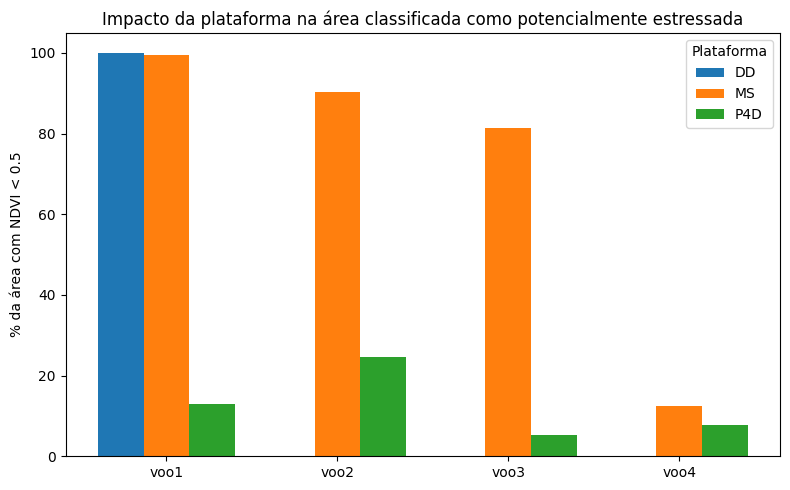

✅ Figura salva em: /content/drive/MyDrive/artigo 2/figuras/impacto_agronomico.png


In [ ]:
import matplotlib.pyplot as plt

LIMIAR_FOCO = 0.5
df_foco = df_impacto[df_impacto["limiar_ndvi"] == LIMIAR_FOCO]

fig, ax = plt.subplots(figsize=(8, 5))
voos_unicos = sorted(df_foco["voo"].unique())
plataformas_unicas = sorted(df_foco["plataforma"].unique())
largura = 0.8 / len(plataformas_unicas)

for i, plat in enumerate(plataformas_unicas):
    sub = df_foco[df_foco["plataforma"] == plat].set_index("voo").reindex(voos_unicos)
    x = np.arange(len(voos_unicos)) + i * largura
    ax.bar(x, sub["pct_area_abaixo"], width=largura, label=plat)

ax.set_xticks(np.arange(len(voos_unicos)) + largura * (len(plataformas_unicas)-1) / 2)
ax.set_xticklabels(voos_unicos)
ax.set_ylabel(f"% da área com NDVI < {LIMIAR_FOCO}")
ax.set_title("Impacto da plataforma na área classificada como potencialmente estressada")
ax.legend(title="Plataforma")
fig.tight_layout()

out_fig = f"{PASTA_PROJETO}/figuras/impacto_agronomico.png"
os.makedirs(os.path.dirname(out_fig), exist_ok=True)
fig.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()
print(f"✅ Figura salva em: {out_fig}")

In [ ]:
# ==========================================================
# HETEROCEDASTICIDADE NO BLAND-ALTMAN
# Verifica se a magnitude da diferença entre plataformas
# aumenta com o valor médio do índice (viés dependente da escala)
# ==========================================================
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import itertools

linhas_heterocedasticidade = []

for voo in VOOS:
    dict_indices, mascara = dados[voo]
    for indice in INDICES:
        arr_por_plataforma = dict_indices[indice]
        plataformas_disponiveis = list(arr_por_plataforma.keys())

        for p1, p2 in itertools.combinations(plataformas_disponiveis, 2):
            arr1 = arr_por_plataforma[p1]
            arr2 = arr_por_plataforma[p2]

            valido = mascara & ~np.isnan(arr1) & ~np.isnan(arr2)
            if valido.sum() < 10:
                continue

            v1 = arr1[valido]
            v2 = arr2[valido]
            media = (v1 + v2) / 2
            diff = v2 - v1
            diff_abs = np.abs(diff)

            # Correlação entre |diferença| e valor médio:
            # se positiva e forte, indica heterocedasticidade
            # (erro cresce com a magnitude do índice)
            r_heterocedasticidade, p_valor = pearsonr(media, diff_abs)

            linhas_heterocedasticidade.append({
                "voo": voo,
                "indice": indice,
                "par": f"{ROTULO.get(p1,p1)} × {ROTULO.get(p2,p2)}",
                "r_|diff|_vs_media": round(r_heterocedasticidade, 4),
                "p_valor": round(p_valor, 6),
                "heterocedastico": "SIM" if (abs(r_heterocedasticidade) > 0.3 and p_valor < 0.05) else "não",
                "n_pixels": int(valido.sum()),
            })

df_heterocedasticidade = pd.DataFrame(linhas_heterocedasticidade)
out_csv = f"{PASTA_PROJETO}/heterocedasticidade.csv"
df_heterocedasticidade.to_csv(out_csv, index=False)
print(f"✅ Salvo em: {out_csv}\n")
print(df_heterocedasticidade.to_string(index=False))

print(f"\nResumo: {df_heterocedasticidade['heterocedastico'].value_counts().to_dict()}")

✅ Salvo em: /content/drive/MyDrive/artigo 2/heterocedasticidade.csv

 voo indice      par  r_|diff|_vs_media  p_valor heterocedastico  n_pixels
voo1   ndvi  DD × MS            -0.1701      0.0             não    490586
voo1   ndvi DD × P4D            -0.1496      0.0             não    490586
voo1   ndvi MS × P4D            -0.7064      0.0             SIM    490586
voo1  osavi  DD × MS             0.8992      0.0             SIM    490586
voo1  osavi DD × P4D            -0.9857      0.0             SIM    490586
voo1  osavi MS × P4D             0.0405      0.0             não    490586
voo1   rdvi  DD × MS             0.8506      0.0             SIM    490586
voo1   rdvi DD × P4D            -0.8515      0.0             SIM    490586
voo1   rdvi MS × P4D            -0.1226      0.0             não    490586
voo2   ndvi  DD × MS            -0.7081      0.0             SIM    389185
voo2   ndvi DD × P4D            -0.3956      0.0             SIM    389185
voo2   ndvi MS × P4D           

In [ ]:
# ==========================================================
# SENSIBILIDADE À REAMOSTRAGEM
# Testa se CCC e RMSE mudam muito ao reduzir a grade de
# comparação (simulado por agregação de blocos a partir dos
# arrays 1000x1000 já carregados em `dados`)
# ==========================================================
import numpy as np
import pandas as pd
import itertools

def ccc_lin(x, y):
    mx, my = np.mean(x), np.mean(y)
    sx, sy = np.std(x), np.std(y)
    r = np.corrcoef(x, y)[0, 1]
    return (2 * r * sx * sy) / (sx**2 + sy**2 + (mx - my)**2)

def block_mean(arr, fator):
    """Agrega blocos fator x fator usando média (ignorando NaN)."""
    h, w = arr.shape
    h2, w2 = h // fator, w // fator
    arr_rec = arr[:h2*fator, :w2*fator].reshape(h2, fator, w2, fator)
    return np.nanmean(arr_rec, axis=(1, 3))

# Fatores de downsample a partir da grade 1000x1000 original:
# 1 -> ~1.000.000 px | 2 -> ~250.000 px | 5 -> ~40.000 px | 10 -> ~10.000 px
FATORES = [1, 2, 5, 10]

linhas_sensibilidade = []

for voo in VOOS:
    dict_indices, mascara = dados[voo]
    for indice in INDICES:
        arr_por_plataforma = dict_indices[indice]
        plataformas_disponiveis = list(arr_por_plataforma.keys())

        for fator in FATORES:
            if fator == 1:
                mascara_f = mascara
                arrays_f = arr_por_plataforma
            else:
                mascara_f = block_mean(mascara.astype(float), fator) >= 0.5
                arrays_f = {p: block_mean(arr, fator) for p, arr in arr_por_plataforma.items()}

            for p1, p2 in itertools.combinations(plataformas_disponiveis, 2):
                a1, a2 = arrays_f[p1], arrays_f[p2]
                valido = mascara_f & ~np.isnan(a1) & ~np.isnan(a2)
                if valido.sum() < 10:
                    continue
                v1, v2 = a1[valido], a2[valido]

                linhas_sensibilidade.append({
                    "voo": voo,
                    "indice": indice,
                    "par": f"{ROTULO.get(p1,p1)} × {ROTULO.get(p2,p2)}",
                    "fator_downsample": fator,
                    "n_pixels_aprox": int(valido.sum()),
                    "CCC": round(ccc_lin(v1, v2), 4),
                    "RMSE": round(np.sqrt(np.mean((v2 - v1) ** 2)), 5),
                })

df_sensibilidade = pd.DataFrame(linhas_sensibilidade)
out_csv = f"{PASTA_PROJETO}/sensibilidade_reamostragem.csv"
df_sensibilidade.to_csv(out_csv, index=False)
print(f"✅ Salvo em: {out_csv}\n")
print(df_sensibilidade.to_string(index=False))

✅ Salvo em: /content/drive/MyDrive/artigo 2/sensibilidade_reamostragem.csv

 voo indice      par  fator_downsample  n_pixels_aprox     CCC    RMSE
voo1   ndvi  DD × MS                 1          490586  0.9303 0.08627
voo1   ndvi DD × P4D                 1          490586  0.2097 0.52334
voo1   ndvi MS × P4D                 1          490586  0.2794 0.49020
voo1   ndvi  DD × MS                 2          122866  0.9410 0.07824
voo1   ndvi DD × P4D                 2          122866  0.2071 0.52295
voo1   ndvi MS × P4D                 2          122866  0.2773 0.48934
voo1   ndvi  DD × MS                 5           19622  0.9469 0.07069
voo1   ndvi DD × P4D                 5           19622  0.1940 0.52240
voo1   ndvi MS × P4D                 5           19622  0.2628 0.48762
voo1   ndvi  DD × MS                10            4910  0.9470 0.06613
voo1   ndvi DD × P4D                10            4910  0.1760 0.52204
voo1   ndvi MS × P4D                10            4910  0.2410 0.48627
v

In [ ]:
pivot = df_sensibilidade.pivot_table(
    index=["voo", "indice", "par"], columns="fator_downsample", values="CCC"
).reset_index()
pivot["delta_CCC_1_vs_10"] = (pivot[1] - pivot[10]).abs()

print(pivot.sort_values("delta_CCC_1_vs_10", ascending=False).to_string(index=False))
print(f"\nDelta médio |CCC(1M px) - CCC(10k px)|: {pivot['delta_CCC_1_vs_10'].mean():.4f}")
print(f"Delta máximo: {pivot['delta_CCC_1_vs_10'].max():.4f}")

 voo indice      par       1       2       5      10  delta_CCC_1_vs_10
voo4   ndvi P4D × MS  0.6593  0.6715  0.6946  0.7406             0.0813
voo2  osavi  DD × MS -0.3178 -0.3211 -0.3058 -0.2766             0.0412
voo1   ndvi MS × P4D  0.2794  0.2773  0.2628  0.2410             0.0384
voo1   ndvi DD × P4D  0.2097  0.2071  0.1940  0.1760             0.0337
voo2   rdvi  DD × MS -0.3154 -0.3194 -0.3067 -0.2820             0.0334
voo2   rdvi DD × P4D -0.1014 -0.1067 -0.1162 -0.1319             0.0305
voo2  osavi DD × P4D -0.0383 -0.0416 -0.0496 -0.0653             0.0270
voo2   rdvi MS × P4D  0.0694  0.0727  0.0811  0.0956             0.0262
voo2   ndvi MS × P4D  0.2245  0.2293  0.2376  0.2489             0.0244
voo1  osavi  DD × MS  0.2139  0.2152  0.2059  0.1897             0.0242
voo1   rdvi  DD × MS  0.1678  0.1692  0.1619  0.1490             0.0188
voo1   ndvi  DD × MS  0.9303  0.9410  0.9469  0.9470             0.0167
voo1   rdvi DD × P4D  0.0730  0.0737  0.0694  0.0623            